from 2023

# 基本原理
PS: 额外插一句, plan模型有的时候在plan中就加入了reflection思想

## 基本思想
以考试笔试为例子, 第一遍完成后, 记为完成**初稿**. 这是这个时候, 可能因为马虎大意或者知识点不熟悉, 可能在初稿中犯了一点点错误, 这个时候我们要对初稿进行修正. 通过审查初稿得到的**反馈**, 不断完善初稿, 形成**修订稿**.

概括为: 
- 执行: 使用常规方法完成初稿
- 反思: 审查初稿, 给出反馈
- 优化: 结合初稿和反馈, 形成预定稿

## 公式化: 
在上面的基础上, 引入两个专门refine过的大模型, $\pi_{reflect}$ 和 $\pi_{refine}$
结合任务和初稿, 生成反馈
$$
F_i = \pi_{\text{reflect}}(\text{Task}, O_i)
$$
结合任务、初稿和反馈, 形成修订稿
$$
O_{i+1} = \pi_{\text{refine}}(\text{Task}, O_i, F_i)
$$
注意, 这是一个不断循环的迭代过程, 不断迭代, 知道达到要求

## 实现细节

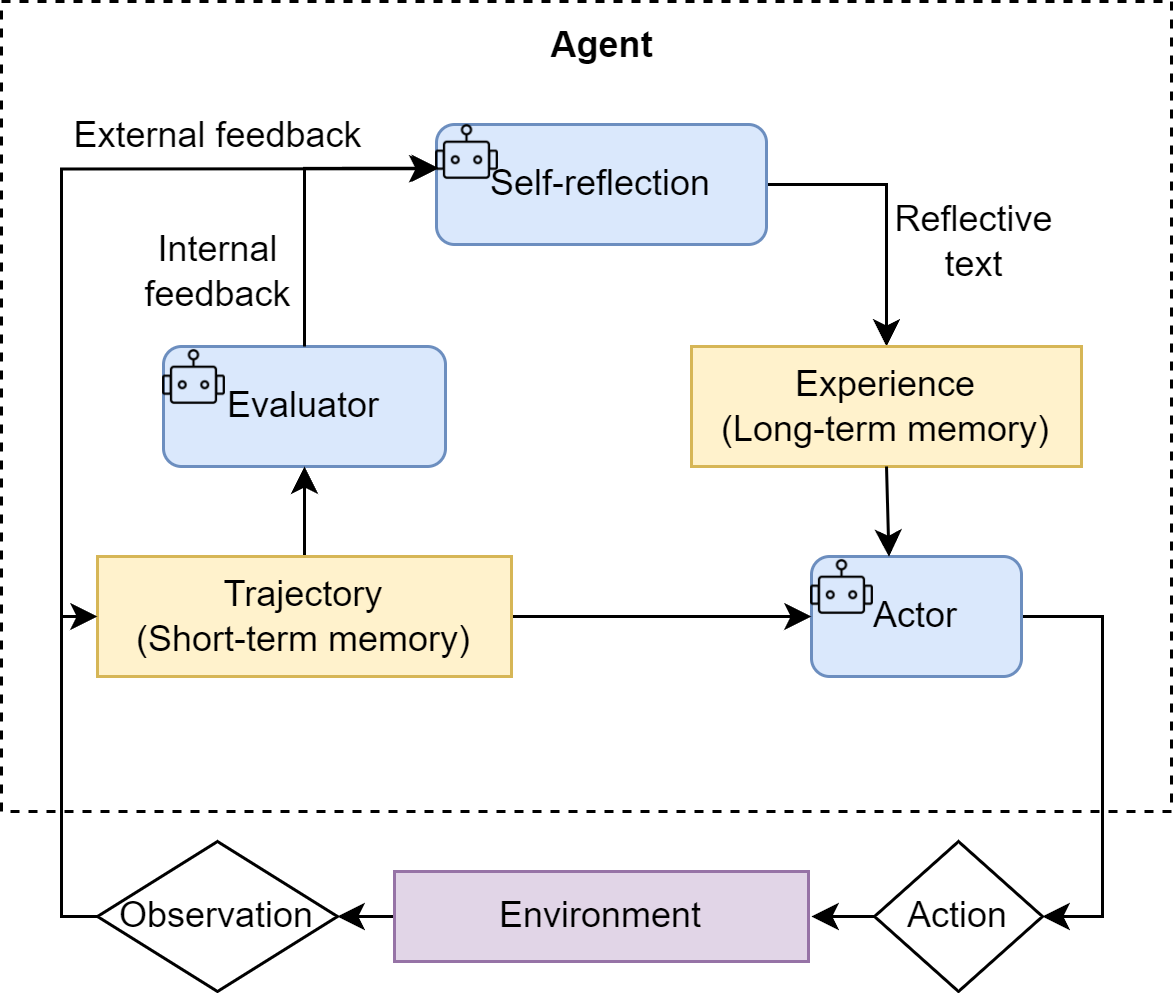


原来的ReAct只有这些, 现在我通过reflection(图中是self-reflection)结合内部和外部反馈形成了记忆, 输入给actor. 给予actor更加丰富的上下文

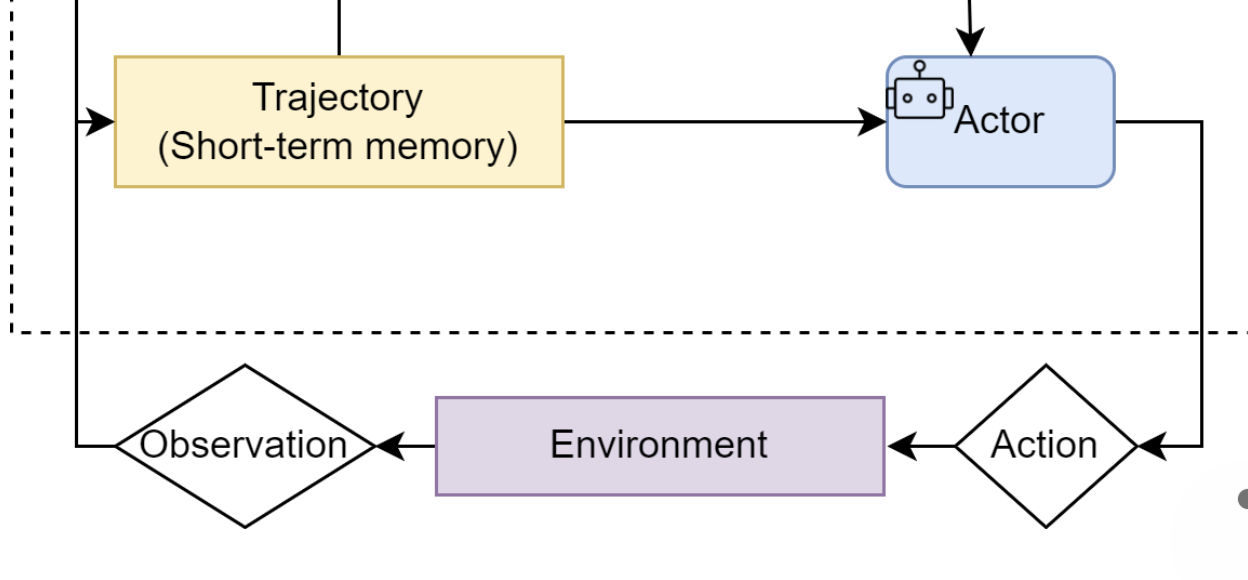

**优势**:
- 提供内部纠错回路
- 将单次的任务执行变为持续优化的过程
- 构造了短期记忆

## 核心: 上下文管理


## 收益: 以成本换质量

问题:
- 串行, 依旧是串行, 势必会浪费很多时间
- 多次调用llm, 成本变高

收益:
- 输出准确性的提高

### 上下文管理


In [48]:
from typing import List, Dict, Any, Literal

# type 不方便作为参数名

class ReflectionMemory:
    def __init__(self):
        self.memory: List[Dict[str, Any]] = []


    def add_memory(self, memory_type:Literal['execution', 'reflection'], content:str):
        new_memory = {
            "memory_type": memory_type,
            "content": content
        }
        self.memory.append(new_memory)
        print(f"a new memory is added:{memory_type}; {content[:20]}\n") # content剪切一下打印内容过多


    def export_memory(self):
        trajectory_parts = []
        for i in self.memory:
            if i.get("memory_type") == "execution":
                trajectory_parts.append(f"--- last attempt ---\n{i.get('content')}")
            if i.get("memory_type") == "reflection":
                trajectory_parts.append(f"--- reflection ---\n{i.get('content')}")
        format_memory = '\n\n'.join(trajectory_parts)
        print(f"format_memory: \n{format_memory}")
        return format_memory
    

    def get_last_execution(self):
        for i in reversed(self.memory):
            if i['memory_type'] == "execution":
                # print(f"last attempt: {i['content']}") # 不print了, 不然太乱
                return i['content'] 
            
        return None

In [49]:
# 测试一下
my_reflection_memory = ReflectionMemory()
my_reflection_memory.add_memory(
    memory_type="execution",
    content="1+1=2"
)
my_reflection_memory.add_memory(
    memory_type="reflection",
    content="success"
)
my_reflection_memory.export_memory()
# my_reflection_memory.get_last_execution()

a new memory is added:execution; 1+1=2

a new memory is added:reflection; success

format_memory: 
--- last attempt ---
1+1=2

--- reflection ---
success


'--- last attempt ---\n1+1=2\n\n--- reflection ---\nsuccess'

### 提示词

In [50]:
# 为了简便, 我们这里将常规方法简化为单次问答


In [51]:
from string import Template
PROMPT = Template("""
You are a senior Python developer. Please write a Python function according to the requirements below.
Your code must include the complete function signature and a docstring, and it must follow the PEP 8 coding style guide.

Requirements: $task

Please output only the code and do not include any additional explanation.
""")

In [52]:
from string import Template
REFLECT_PROMPT = Template("""
You are an extremely strict code review expert and a senior algorithm engineer, with uncompromising demands for code performance.
Your task is to review the Python code below and focus on identifying the main bottlenecks in terms of <strong>algorithmic efficiency</strong>.

# Original task:
$task

# Code under review:
```python
$code

Please analyze the time complexity of the code and consider whether there is a <strong>algorithmically superior</strong> solution that can significantly improve performance.
If such a solution exists, clearly point out the shortcomings of the current algorithm and propose specific, feasible algorithmic improvements (e.g., using a sieve instead of trial division).
If the code is already optimal at the algorithmic level, you may answer “No improvements needed.”

Please output your feedback directly, without any additional explanation.
""")

In [53]:
from string import Template
REFINE_PROMPT = Template("""
You are a senior Python developer. You are optimizing your code based on feedback from a code review expert.

# Original task:
$task

# Your previous code attempt:
$last_code

Reviewer feedback:
$feedback

Please generate a new, optimized version of the code based on the reviewer's feedback.
Your code must include the complete function signature and a docstring, and it must follow the PEP 8 coding style guide.
Please output only the optimized code and do not include any additional explanation.
""")

### 开始主循环

In [54]:
%cd ../

from mylib import MyLLM

/


In [63]:
class ReflectionAgent:
    def __init__(self, llm: MyLLM, max_step: int = 5):
        self.client = llm
        self.max_step = max_step
        self.memory = ReflectionMemory()

    def run(self, question: str):
        # 先形成初稿
        prompt = PROMPT.substitute(
            task = question
        )
        messages = [
            {"role": "user", "content": prompt}
        ]
        first_draft = self.client.generate(
            messages
        )
        self.memory.add_memory(
            memory_type="execution",
            content=first_draft
        )

        # 迭代审查
        for i in range(self.max_step):
            print('='*60)
            print(f"第{i+1}轮")
            print('='*60)

            # reflection
            print('-'*20 + 'reflection' + '-'*20)
            prompt = REFLECT_PROMPT.substitute(
                task = question,
                code = self.memory.get_last_execution()
            )
            messages = [
                {"role": "user", "content": prompt}
            ]
            reflection = self.client.generate(
                messages
            )
            self.memory.add_memory(
                memory_type="reflection",
                content=reflection
            )

            # check
            if "No improvements needed" in reflection:
                break

            # refine
            print('-'*20 + 'refine' + '-'*20)
            prompt = REFINE_PROMPT.substitute(
                task = question,
                last_code = self.memory.get_last_execution(),
                feedback = reflection
            )
            messages = [ 
                {"role": "user", "content": prompt}
            ]
            refined_draft = self.client.generate(
                messages
            )
            self.memory.add_memory(
                memory_type="execution",
                content=refined_draft
            )
        return self.memory.get_last_execution()


In [64]:
my_llm = MyLLM()

reflectin_agent = ReflectionAgent(
    llm = my_llm
)
result = reflectin_agent.run(
    question="Write a Python function to find all prime numbers between 1 and 100"
)
result

llm输入: 
[{'role': 'user', 'content': '\nYou are a senior Python developer. Please write a Python function according to the requirements below.\nYour code must include the complete function signature and a docstring, and it must follow the PEP 8 coding style guide.\n\nRequirements: Write a Python function to find all prime numbers between 1 and 100\n\nPlease output only the code and do not include any additional explanation.\n'}]

llm输出: 
```python
def find_primes_up_to_100() -> list:
    """
    Find all prime numbers between 1 and 100 (inclusive).

    Returns:
        A list of integers representing all prime numbers in the range [1, 100].
        Note: By definition, 1 is not a prime number, so the list starts from 2.
    """
    primes = []
    for num in range(2, 101):
        is_prime = True
        for divisor in range(2, int(num ** 0.5) + 1):
            if num % divisor == 0:
                is_prime = False
                break
        if is_prime:
            primes.append(

'```python\ndef find_primes_up_to_100() -> list:\n    """\n    Find all prime numbers between 1 and 100 (inclusive) using the Sieve of Eratosthenes.\n\n    Returns:\n        A list of integers representing all prime numbers in the range [2, 100].\n        Note: By definition, 1 is not a prime number, so the list starts from 2.\n    """\n    n = 100\n    if n < 2:\n        return []\n    sieve = [True] * (n + 1)\n    sieve[0] = sieve[1] = False\n    for i in range(2, int(n ** 0.5) + 1):\n        if sieve[i]:\n            for j in range(i * i, n + 1, i):\n                sieve[j] = False\n    return [i for i in range(2, n + 1) if sieve[i]]\n```'